In [17]:
# https://www.kaggle.com/competitions/mortys-time-paradox-aicc-round-3/overview

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from itertools import permutations

In [18]:
train = pd.read_csv("/kaggle/input/mortys-time-paradox-aicc-round-3/train.csv")
test = pd.read_csv("/kaggle/input/mortys-time-paradox-aicc-round-3/test.csv")
subm = pd.read_csv("/kaggle/input/mortys-time-paradox-aicc-round-3/sample_submission.csv")

train.shape, test.shape, subm.shape

((1000, 14), (1500, 9), (1500, 2))

In [19]:
train.head()

,row_id,x0,x1,x2,x3,x4,x5,x6,x7,cand_0,cand_1,cand_2,cand_3,cand_4
0,0,7.375443,7.594473,9.544929,6.520722,2.372413,10.663466,3.299048,0.106828,1,1,1,0,1
1,1,3.951550,0.546280,1.174609,3.690618,4.712680,6.713291,16.106090,8.096262,1,1,0,1,1
2,2,4.694340,5.452364,6.871558,17.248974,5.753371,10.661893,6.889901,0.849919,1,1,1,1,0
3,3,6.391707,6.135356,6.547818,5.184772,0.858473,9.893235,16.204758,17.211263,1,1,1,0,1
4,4,0.981253,10.000388,4.012973,10.201618,6.817579,0.993900,12.933634,3.246264,1,1,1,1,0


In [20]:
test.head()

,row_id,x0,x1,x2,x3,x4,x5,x6,x7
0,0,4.742837,11.644803,1.123700,4.658670,8.634414,12.837261,9.163153,1.372486
1,1,5.691666,5.162872,6.697662,10.552433,1.764172,4.570268,4.370320,10.325156
2,2,8.118066,1.369183,15.258635,14.401229,4.727289,2.297633,12.644616,13.826028
3,3,5.496239,0.294445,4.244888,8.278670,1.056640,4.377684,11.149974,3.254449
4,4,5.057256,5.841208,9.381881,2.268179,7.282043,5.627389,0.534152,18.159529


In [21]:
train.max()

row_id    999.000000
x0         10.999272
x1         12.996184
x2         16.997881
x3         18.978198
x4         10.994167
x5         12.991039
x6         16.984352
x7         18.983786
cand_0      1.000000
cand_1      1.000000
cand_2      1.000000
cand_3      1.000000
cand_4      1.000000
dtype: float64

In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler1, scaler2 = MinMaxScaler(), StandardScaler()

features = [f'x{i}' for i in range(8)]
train.loc[:, features] = scaler1.fit_transform(train.loc[:, features])
test.loc[:, features] = scaler1.transform(test.loc[:, features])

train[[f+'sin' for f in features]] = np.sin(train.loc[:, features] * 2 * np.pi)
train[[f+'cos' for f in features]] = np.cos(train.loc[:, features] * 2 * np.pi)
test[[f+'sin' for f in features]] = np.sin(test.loc[:, features] * 2 * np.pi)
test[[f+'cos' for f in features]] = np.cos(test.loc[:, features] * 2 * np.pi)

features = [c for c in train.columns if c not in ['row_id'] + [f'cand_{i}' for i in range(5)] + features]

train.loc[:, features] = scaler2.fit_transform(train.loc[:, features])
test.loc[:, features] = scaler2.transform(test.loc[:, features])

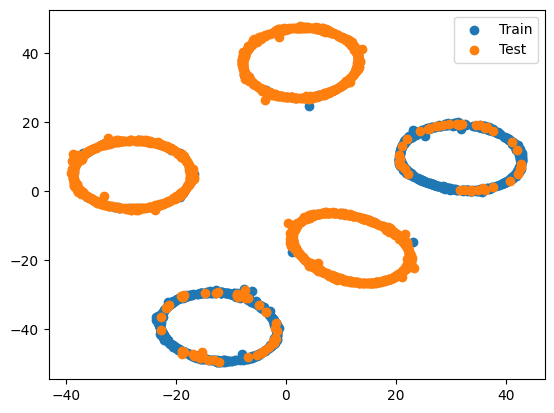

In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=50, random_state=2026)

X_tsne = tsne.fit_transform(pd.concat([train[features], test[features]]))

plt.scatter(X_tsne[:len(train), 0], X_tsne[:len(train), 1], label='Train')
plt.scatter(X_tsne[len(train):, 0], X_tsne[len(train):, 1], label='Test')
plt.legend()
plt.show()

In [24]:
full = pd.concat([train[features], test[features]]).values
full.shape

(2500, 16)

In [25]:
from sklearn.cluster import SpectralClustering

clusterer = SpectralClustering(n_clusters=5)

clusters = clusterer.fit_predict(full)
clusters

array([4, 2, 2, ..., 3, 3, 1], dtype=int32)

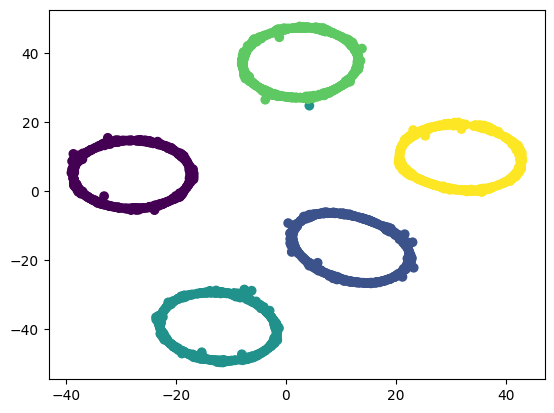

In [26]:
plt.scatter(X_tsne[:len(train), 0], X_tsne[:len(train), 1], c=clusters[:len(train)])
plt.scatter(X_tsne[len(train):, 0], X_tsne[len(train):, 1], c=clusters[len(train):])
plt.show()

In [27]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

probs = ohe.fit_transform(clusters.reshape(-1, 1)).toarray()

In [28]:
train_probs = probs[:len(train)]

results = []

for order in list(permutations(range(5))):
    score = train[[f'cand_{i}' for i in range(5)]].values[np.arange(len(train)), train_probs[:, order].argmax(axis=1)].mean()
    results.append((order, score))

order, score = sorted(results, key=lambda x: -x[1])[0]
order, score

((3, 4, 1, 2, 0), np.float64(0.999))

In [29]:
probs = probs[:, order]

In [30]:
test_probs = probs[len(train):]
y_pred = test_probs.argmax(axis=1)

subm = pd.DataFrame({
    'row_id': test['row_id'],
    'label': y_pred
})

subm.to_csv('submission.csv', index=False)

subm.head()

,row_id,label
0,0,4
1,1,2
2,2,2
3,3,4
4,4,0
